# Analisa Data Menggunakan Naive Bayes
Naive Bayes adalah algoritma klasifikasi yang bekerja berdasarkan perhitungan peluang. Sederhananya, model ini melihat data masa lalu untuk menghitung seberapa besar peluang suatu kejadian terjadi di masa depan berdasarkan ciri-ciri yang ada.

Disebut "Naive" karena algoritma ini menganggap semua ciri (fitur) dalam data tidak saling berkaitan satu sama lain. Meskipun asumsi ini sangat sederhana, Naive Bayes dikenal sangat cepat dan efektif, terutama untuk kasus klasifikasi medis atau teks.

## Dataset yang Digunakan
Pada tugas ini saya menggunakan dataset Heart-Disease-Prediction. Dataset ini merupakan data klinis yang digunakan untuk memprediksi risiko penyakit jantung pada pasien. Terdapat total 303 baris data dengan berbagai parameter medis seperti usia, tekanan darah, kadar kolesterol, hingga hasil tes kesehatan lainnya.

Dalam proses pengolahan, dataset ini diklasifikasikan ke dalam dua kategori (label 1 dan 0) menggunakan algoritma Naive Bayes. Tujuan utamanya adalah untuk melihat sejauh mana model mampu membedakan pasien yang memiliki risiko penyakit jantung dengan yang tidak berdasarkan indikator medis yang tersedia.

## Pengimplementasian Menggunakan Python
Bagian ini menjelaskan bagaimana kodingan Python bekerja di dalam KNIME untuk mengolah data secara otomatis.

In [ ]:
# Import Library & Ambil Data
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
import knime.scripting.io as knio

df = knio.input_tables[0].to_pandas()

- Fungsi: Memanggil library pendukung dan mengubah data dari KNIME menjadi tabel Pandas agar bisa diproses oleh Python.

In [ ]:
# Label Encoding
en = LabelEncoder()
df['target'] = en.fit_transform(df['target'])

- Fungsi: Mengubah label teks pada kolom target menjadi angka (0 atau 1) karena model matematika hanya bisa menghitung data numerik.

In [ ]:
# Pemisahan Fitur (X) dan Target (y)
X = df.drop('target', axis=1)
y = df['target']

- Fungsi: Membagi data menjadi dua bagian: X sebagai variabel pendukung (input) dan y sebagai variabel yang ingin ditebak (output).

In [ ]:
# Feature Scaling
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

- Fungsi: Menyamakan skala semua angka pada fitur agar fitur dengan nilai besar tidak mendominasi model, sehingga hasil prediksi lebih stabil.

In [ ]:
# Training & Prediksi
model = GaussianNB()
model.fit(X_scaled, y)
predictions = model.predict(X_scaled)

- Fungsi: Melatih model Gaussian Naive Bayes untuk mengenali pola data (fit), lalu melakukan prediksi atau tebakan berdasarkan pola tersebut.

In [ ]:
# Output Kembali ke KNIME
output_df = df.copy()
output_df['prediction'] = predictions
knio.output_tables[0] = knio.Table.from_pandas(output_df)

- Fungsi: Memasukkan hasil prediksi ke kolom baru dan mengirimkan tabel lengkapnya kembali ke KNIME untuk dievaluasi oleh node Scorer.

## Pengimplementasian Menggunakan KNIME
KNIME berfungsi sebagai wadah untuk menyusun alur kerja (workflow) dari awal sampai akhir. menggabungkan node visual KNIME dengan kodingan Python agar hasilnya lebih maksimal.

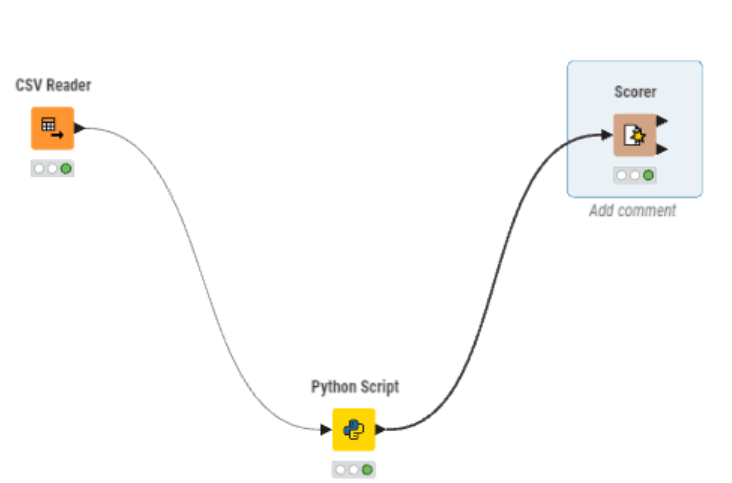

### 1. CSV Reader
Digunakan untuk memasukkan file dataset ke dalam KNIME agar siap diolah.

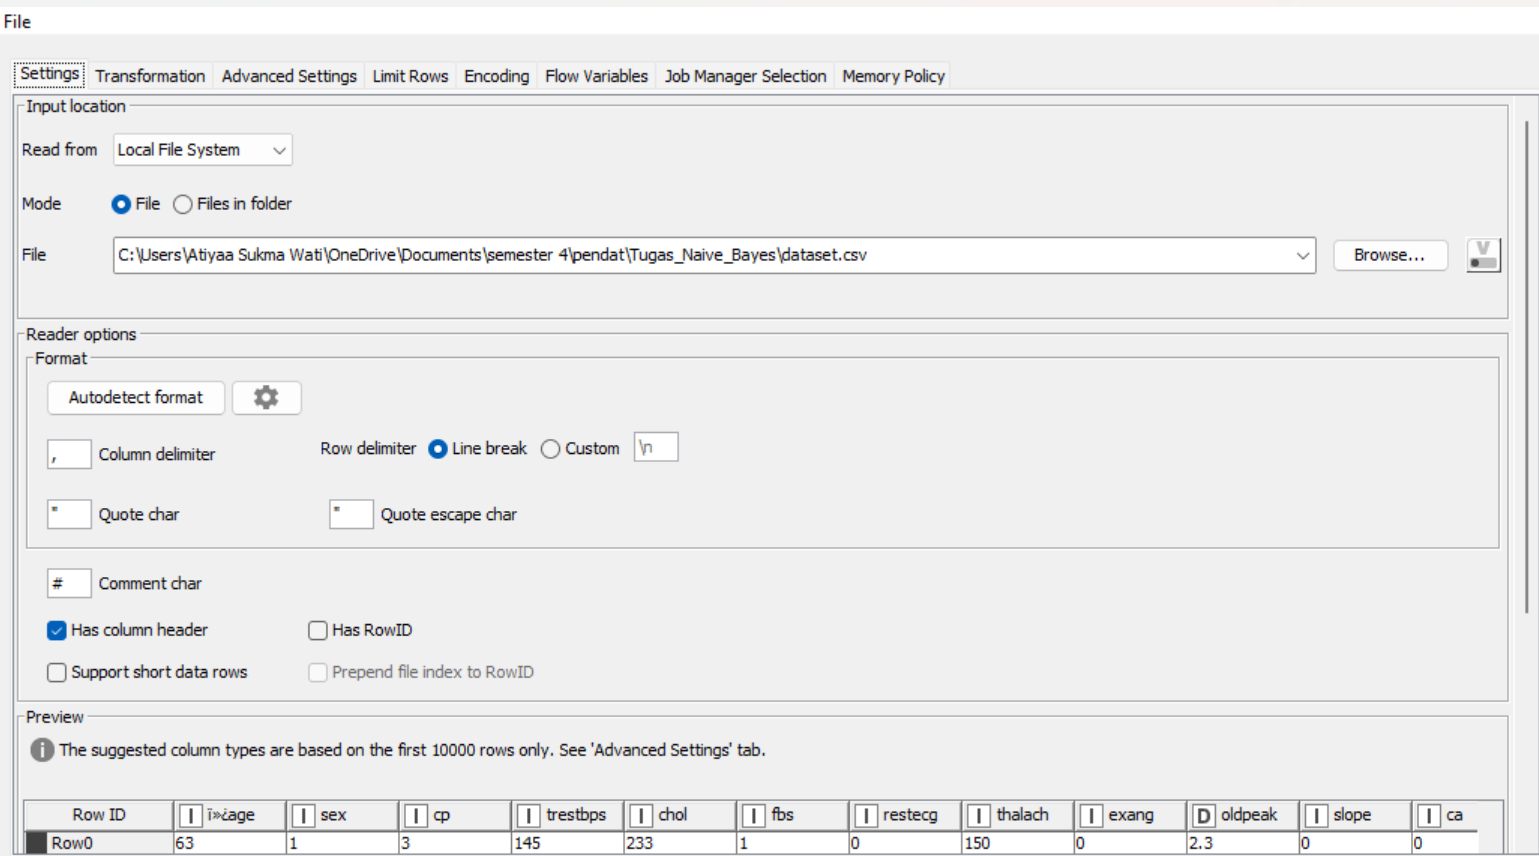


### 2. Python Script
Bagian ini berfungsi sebagai unit pemrosesan utama. Penggunaan skrip Python secara mandiri memberikan kontrol penuh dalam mempersiapkan data sebelum masuk ke tahap klasifikasi. Terdapat tiga proses utama di dalamnya:

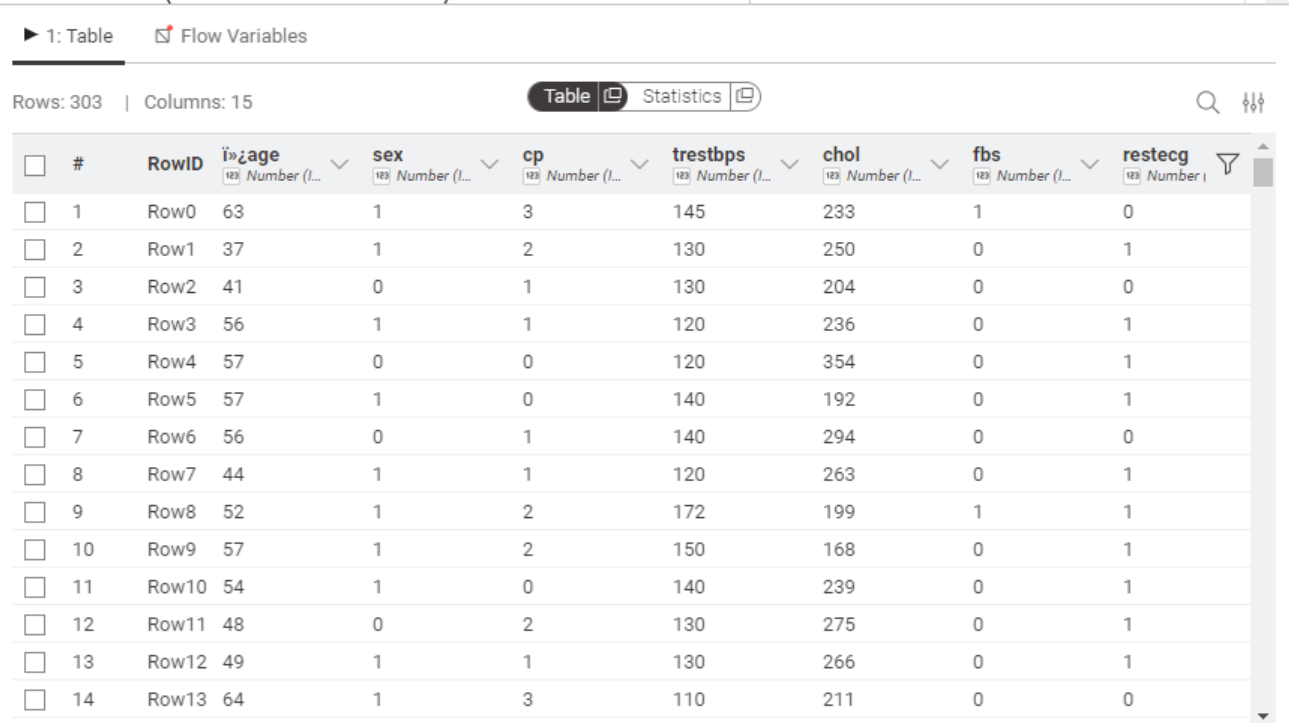

Data tersebut merupakan dataset berjumlah 303 baris yang berisi informasi kesehatan pasien, seperti usia, tekanan darah, dan kadar kolesterol. Tabel ini menjadi bahan utama yang diolah menggunakan Python Script di dalam KNIME.

### 3. Scorer
Node Scorer berfungsi sebagai alat evaluasi untuk mengukur sejauh mana tingkat keberhasilan dan keakuratan model Naive Bayes yang telah dibuat. Secara teknis, node ini membandingkan data asli (label aktual) dengan data tebakan (hasil prediksi) yang dihasilkan dari kodingan Python sebelumnya.

#### a. Confusion Matrix

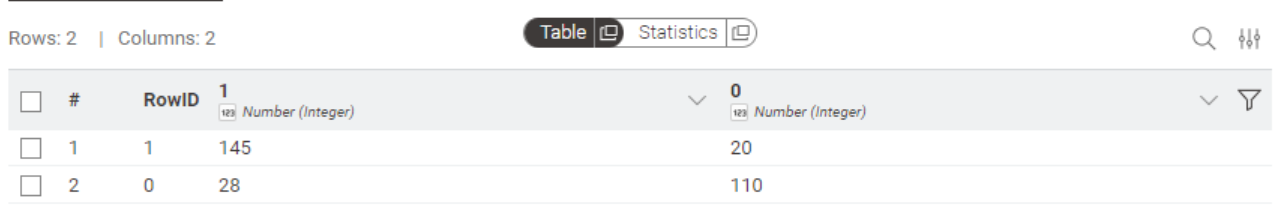

Confusion Matrix menunjukkan performa model melalui perbandingan nilai asli dan prediksi:

- Prediksi Benar: Sebanyak 145 data kelas "1" dan 110 data kelas "0" berhasil ditebak dengan akurat (total 255 data).
- Prediksi Salah: Terdapat 48 data yang gagal diklasifikasikan dengan tepat oleh model.

Kesimpulan: Dominasi jumlah prediksi benar pada garis diagonal tabel ini menghasilkan tingkat akurasi sebesar 83,61%. Hal ini membuktikan bahwa model Naive Bayes yang diimplementasikan memiliki kinerja yang sangat baik dan reliabel.

#### b. Accuracy Statistics
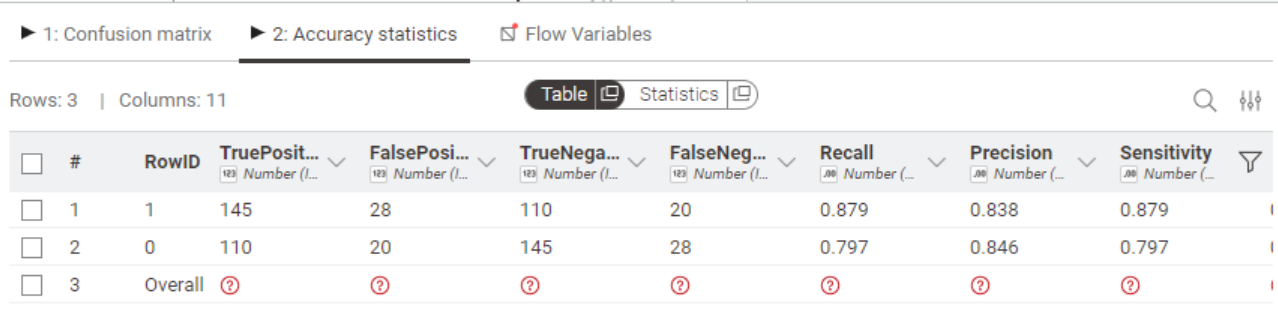

Metrik evaluasi pada tabel memberikan gambaran menyeluruh mengenai performa model:

- True Positive (145) & True Negative (110): Menunjukkan jumlah data yang berhasil diklasifikasikan dengan benar sesuai label aslinya.
- Recall (Sensitivitas): Pada kelas "1" mencapai 0,879, sedangkan pada kelas "0" sebesar 0,797. Ini menunjukkan model sangat kuat dalam mengidentifikasi kasus pada kelas 1.
- Precision: Nilai ketepatan prediksi berada pada angka 0,838 untuk kelas "1" dan 0,846 untuk kelas "0", yang menandakan konsistensi prediksi yang tinggi di kedua kelas.
- Specificity: Sebesar 0,879 pada kelas "0", membuktikan kemampuan model yang sangat baik dalam menyaring data negatif agar tidak terjadi salah klasifikasi.
- F-measure: Memiliki skor 0,858 dan 0,821, yang menunjukkan keseimbangan yang optimal antara presisi dan recall.
- Overall Accuracy: Tingkat keberhasilan total model adalah 0,842 (84,2%).
- Cohen's Kappa: Skor 0,679 mengonfirmasi bahwa hasil klasifikasi ini memiliki tingkat kesepakatan yang kuat secara statistik dan bukan sekadar kebetulan.

Kesimpulan: Secara keseluruhan, perbedaan nilai antara Precision dan Recall di tiap kelas menunjukkan karakteristik model yang lebih sensitif terhadap kelas 1, namun tetap stabil dan reliabel dengan akurasi akhir yang memuaskan.